In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, BatchNormalization, MaxPooling2D
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

## Loading and Preporcessing CIFAR-100 dataset


In [2]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One hot encode the labels
y_train = to_categorical(y_train, num_classes=100)
y_test = to_categorical(y_test, num_classes=100)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


## The AlexNet model (Adjusted for CIFAR-100)
* Adjusted to CIFAR-100's 32 x 32 input size and 100 output classes.
* Reduced FC layers from 4096->1024-> 512 to avoid the overfitting on small images
* Uses ReLU , Dropout, BatchNorm and softmax in the final layer

In [3]:
model = Sequential()

# Layer 1
model.add(Conv2D(96, kernel_size=(3, 3), strides=(1, 1), input_shape=(32, 32, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())

# Layer2
model.add(Conv2D(256, kernel_size=(2, 2), strides=(1 ,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())

# Layer 3
model.add(Conv2D(384, kernel_size=(3, 3), strides=(1, 1), padding='same'))
model.add(Activation('relu'))

# Layer 4
model.add(Conv2D(384, kernel_size=(3, 3), strides=(1, 1), padding='same'))
model.add(Activation('relu'))

# Layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1, 1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Flatten
model.add(Flatten())

# Fully connected Layer 1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(100))
model.add(Activation('softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(loss="categorical_crossentropy",
              optimizer='adam',
              metrics=['accuracy']
              )

In [5]:
history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=15,
                    validation_split=0.2,
                    verbose=1)


Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.1201 - loss: 3.8395 - val_accuracy: 0.0112 - val_loss: 6.4690
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.2359 - loss: 3.1364 - val_accuracy: 0.2423 - val_loss: 3.0931
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.3115 - loss: 2.7272 - val_accuracy: 0.3034 - val_loss: 2.8299
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.3797 - loss: 2.4005 - val_accuracy: 0.3132 - val_loss: 2.7571
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.4349 - loss: 2.1356 - val_accuracy: 0.3663 - val_loss: 2.5120
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.4915 - loss: 1.8783 - val_accuracy: 0.3909 - val_loss: 2.3825
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.5440 - loss: 1.6456 - val_accuracy: 0.3615 - val_loss: 2.6807
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.5982 - loss: 1.4314 - 

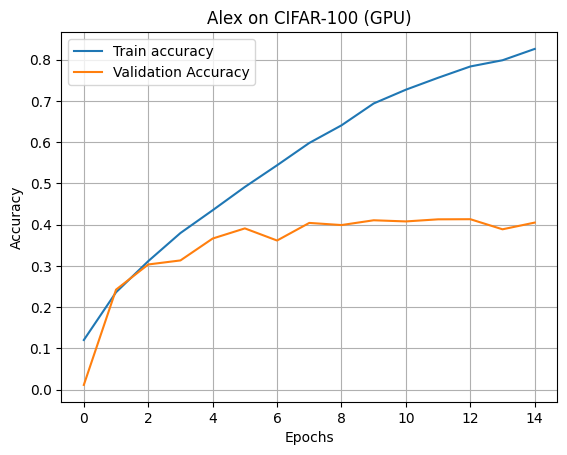

In [7]:
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Alex on CIFAR-100 (GPU)')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)
plt.show()